SOURCE - https://www.mit.edu/~ecprice/wordlist.10000


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

padding = 10
fontsize = 16
sns.set_theme()
plt.rcParams["figure.figsize"] = (12, 6)  
plt.rcParams["axes.titlepad"] = padding 
plt.rcParams["axes.labelpad"] = padding
plt.rcParams["axes.titlesize"] = fontsize 
plt.rcParams["axes.labelsize"] = fontsize 


In [2]:
letters = {'a':0, 'b':0, 'c':0, 'd':0, 'e':0,
           'f':0, 'g':0, 'h':0, 'i':0, 'j':0,
           'k':0, 'l':0, 'm':0, 'n':0, 'o':0,
           'p':0, 'q':0, 'r':0, 's':0, 't':0,
           'u':0, 'v':0, 'w':0, 'x':0, 'y':0,
           'z':0, ' ':0}

total = 0
with open('words_alpha.txt', 'r') as file:
    for line in file:
        total +=1
        for char in line.strip():
            letters[char] += 1

letters

{'a': 295792,
 'b': 63942,
 'c': 152980,
 'd': 113192,
 'e': 376455,
 'f': 39238,
 'g': 82627,
 'h': 92368,
 'i': 313008,
 'j': 5456,
 'k': 26814,
 'l': 194915,
 'm': 105208,
 'n': 251435,
 'o': 251596,
 'p': 113663,
 'q': 5883,
 'r': 246143,
 's': 250282,
 't': 230895,
 'u': 131495,
 'v': 33075,
 'w': 22407,
 'x': 10493,
 'y': 70581,
 'z': 14757,
 ' ': 0}

C:\Users\artyo\AppData\Local\Temp\ipykernel_6504\2523781798.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df_original.replace(letters)


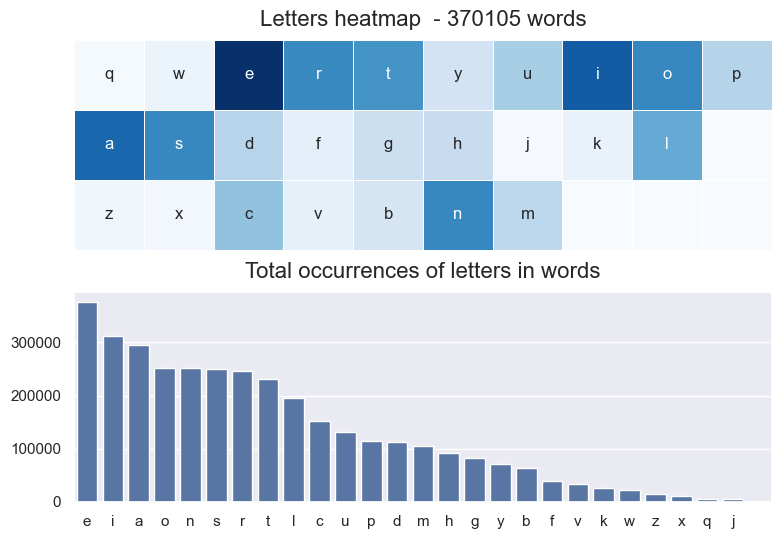

<Figure size 800x200 with 0 Axes>

In [3]:
df_original = pd.read_csv('base.csv', index_col=0)

df = df_original.replace(letters)

fig, ax = plt.subplots(2,1, figsize=(9, 6))
plt.figure(figsize=(8, 2))
sns.heatmap(df, cmap='Blues', linewidths=.5, xticklabels=False, yticklabels=False, cbar=False, annot=df_original, fmt='s', ax = ax[0])

sorted_letters = dict(sorted(letters.items(), key=lambda item: item[1], reverse=True))
sorted_letters
sns.barplot(sorted_letters, ax=ax[1])

ax[0].title.set_text(f"Letters heatmap  - {total} words")
ax[0].set_ylabel("")
ax[1].title.set_text("Total occurrences of letters in words")
ax[1].set_ylabel("")
plt.show()

        

In [4]:
letters = {'a':0, 'b':0, 'c':0, 'd':0, 'e':0,
           'f':0, 'g':0, 'h':0, 'i':0, 'j':0,
           'k':0, 'l':0, 'm':0, 'n':0, 'o':0,
           'p':0, 'q':0, 'r':0, 's':0, 't':0,
           'u':0, 'v':0, 'w':0, 'x':0, 'y':0,
           'z':0, ' ':0}

words = []
total = 0
with open('words_alpha.txt', 'r') as file:
    for line in file:
        if len(line)==6: #since data have \n at the end of each line
            total+=1
            words.append(line.strip())
            for char in line.strip():
                letters[char] += 1

letters

{'a': 8393,
 'b': 2091,
 'c': 2745,
 'd': 2813,
 'e': 7803,
 'f': 1238,
 'g': 1971,
 'h': 2284,
 'i': 5067,
 'j': 376,
 'k': 1743,
 'l': 4247,
 'm': 2494,
 'n': 4044,
 'o': 5219,
 'p': 2299,
 'q': 139,
 'r': 5145,
 's': 6537,
 't': 4189,
 'u': 3361,
 'v': 878,
 'w': 1171,
 'x': 361,
 'y': 2523,
 'z': 474,
 ' ': 0}

C:\Users\artyo\AppData\Local\Temp\ipykernel_6504\977428486.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df_original.replace(letters)


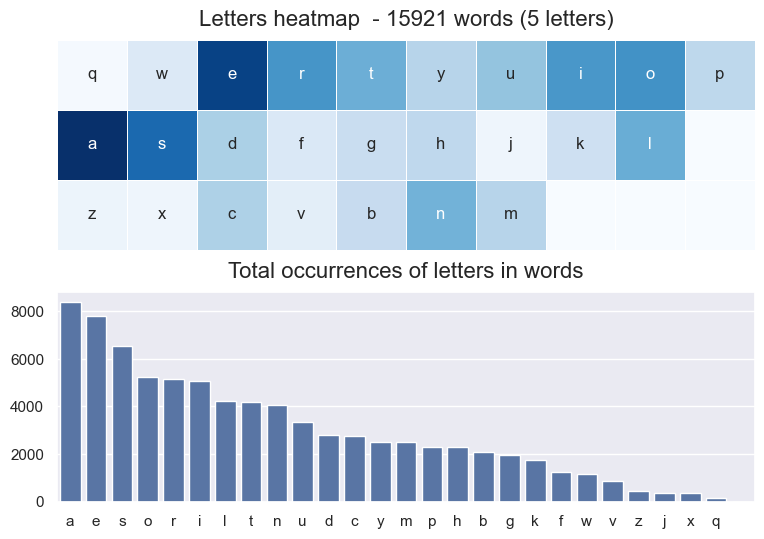

<Figure size 800x200 with 0 Axes>

In [5]:
df = df_original.replace(letters)

fig, ax = plt.subplots(2,1, figsize=(9, 6))
plt.figure(figsize=(8, 2))
sns.heatmap(df, cmap='Blues', linewidths=.5, xticklabels=False, yticklabels=False, cbar=False, annot=df_original, fmt='s', ax = ax[0])

sorted_letters = dict(sorted(letters.items(), key=lambda item: item[1], reverse=True))
sorted_letters
sns.barplot(sorted_letters, ax=ax[1])

ax[0].title.set_text(f"Letters heatmap  - {total} words (5 letters)")
ax[0].set_ylabel("")
ax[1].title.set_text("Total occurrences of letters in words")
ax[1].set_ylabel("")
plt.show()



In [11]:
letter_scores = {}
count = len(sorted_letters)-1
for letter in sorted_letters.keys():
    letter_scores[letter] = count
    # if "aroseuntildc".__contains__(letter):
    #     letter_scores[letter] = -50
    count-=1

scoreboard = pd.DataFrame({"words": words})

def word_score(word):
    word_letters = set(word)
    score = 0
    for letter in word_letters:
        score += letter_scores[letter]
    return score

scoreboard['score'] = scoreboard['words'].apply(word_score)
scoreboard.sort_values(by='score', ascending=False, inplace=True)
#scoreboard.groupby("score").first().sort_index(ascending=False).head(50)
scoreboard
#sns.barplot(x='score', y='words', data=scoreboard.head(20), palette='Blues')

,words,score
12332,seora,120
899,arose,120
10063,oreas,120
13068,solea,118
12348,serai,118
...,...,...
376,ajava,34
374,ajaja,29
7683,kikki,29
15807,xviii,28


In [7]:
letter_scores

{'a': -50,
 'e': -50,
 's': -50,
 'o': -50,
 'r': -50,
 'i': -50,
 'l': -50,
 't': -50,
 'n': -50,
 'u': -50,
 'd': 16,
 'c': 15,
 'y': 14,
 'm': 13,
 'p': 12,
 'h': 11,
 'b': 10,
 'g': 9,
 'k': 8,
 'f': 7,
 'w': 6,
 'v': 5,
 'z': 4,
 'j': 3,
 'x': 2,
 'q': 1,
 ' ': 0}

Lately, my friends and I started to play Wordle in Discord. It becomes our favorite activity to compete in,  as it's fun and integrates with chats and sends cool notifications about the game's result. 

If you don't know about the game yet, it is about guessing the 5-letter word within 6 attempts based on the clues you get on every attempt.

So, as a strategy, I decided to use words that contain the most common letters in them for the first 2-3 attempts to help get as many clues as possible, and guess the correct word within the rest of the attempts.

After analysing a set of English words that contains 370k words, this is how the letter distribution looks. I intentionally made it look like a keyboard to hopefully increase cognitive load.

I assigned each letter a 'score' (a=26, e=25, s=24...), and calculated the score of the word - duplicated letters were not counted. 

As a result - 
